In [62]:
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [63]:
df_analyst=df[df['job_title_short']=='Data Analyst'].copy()

In [64]:
df_analyst= df[df['job_country']=='United States']

In [65]:
df_plot= df_analyst['job_location'].value_counts().head(10).to_frame()
df_plot

,count
job_location,
Anywhere,23021
"New York, NY",7891
"Atlanta, GA",6994
"Chicago, IL",5368
United States,4957
"Washington, DC",4671
"San Francisco, CA",4504
"Dallas, TX",4346
"Austin, TX",4147


In [66]:
import seaborn as sns



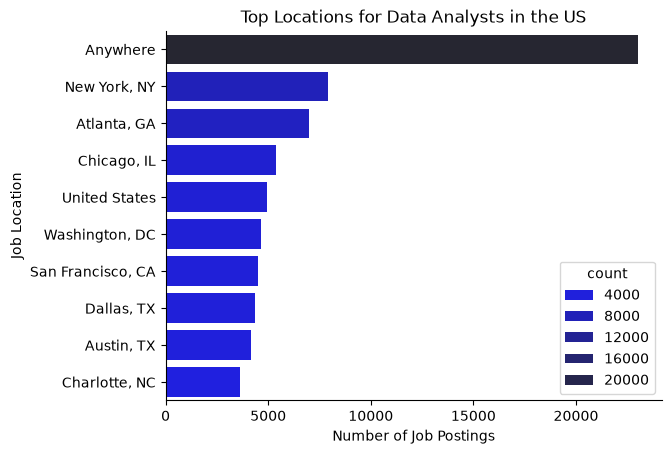

In [67]:
sns.barplot(data=df_plot, x='count', y= 'job_location', hue='count', palette='dark:b_r')
sns.despine()
plt.title('Top Locations for Data Analysts in the US')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Location')
plt.show()

In [69]:
df_DSL = df[df['job_title_short'] == 'Data Scientist'].copy()
df_DSL['job_posted_month_no'] = df_DSL['job_posted_date'].dt.month

df_DSL_explode = df_DSL.explode('job_skills')
df_dsl_pivot = df_DSL_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

# sort columns by total demand, descending
top_5_skills = df_dsl_pivot.sum().sort_values(ascending=False).head(5).index
df_dsl_pivot = df_dsl_pivot[top_5_skills]

df_dsl_pivot = df_dsl_pivot.reset_index()
df_dsl_pivot['job_posted_month'] = df_dsl_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_dsl_pivot = df_dsl_pivot.set_index('job_posted_month')



<Axes: title={'center': 'Top 5 Skills for Data Scientist'}, xlabel='Month', ylabel='Count'>

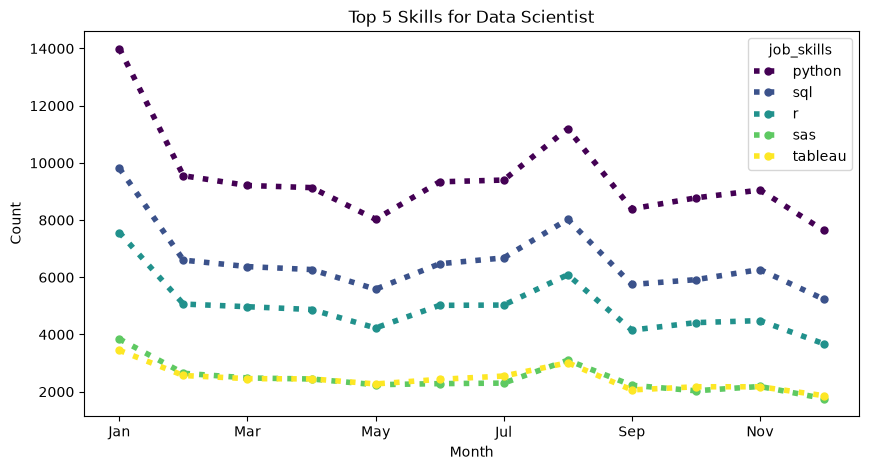

In [70]:
df_dsl_pivot[top_5_skills].plot(
    title='Top 5 Skills for Data Scientist', ylabel='Count', xlabel='Month',
    kind='line', 
    linewidth=4,
    linestyle=':',
    colormap= 'viridis',
    markersize= 5,
    marker= 'o',
    figsize=(10, 5),
    )

In [ ]:
df_DSS = df[df['job_title_short'] == 'Data Scientist'].copy()
df_exploded= df_DSS.explode('job_skills')
skill_stats= df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)
skill_stats= skill_stats.sort_values(by='skill_count', ascending=False).head(20)
skill_stats


,skill_count,median_salary
job_skills,,
python,113711,130500.0
sql,78982,132500.0
r,59566,125000.0
sas,29534,119000.0
tableau,29445,125000.0
aws,26256,132500.0
spark,24286,135000.0
azure,21664,127500.0
tensorflow,19153,140000.0


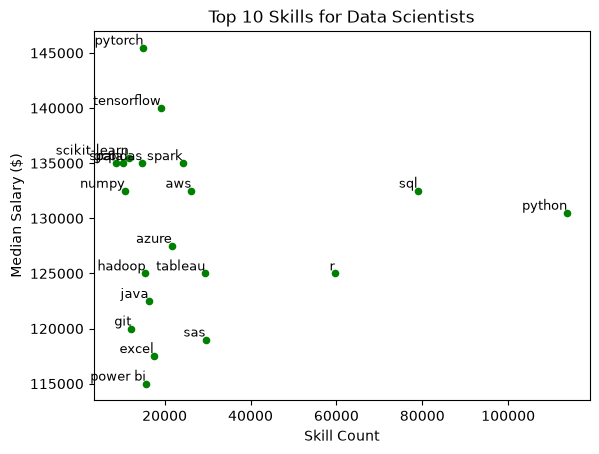

In [ ]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary', color='green')
plt.title('Top 10 Skills for Data Scientists')
plt.xlabel('Skill Count')   
plt.ylabel('Median Salary ($)')

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt, fontsize=9, ha='right', va='bottom')

Text(10.722222222222216, 0.5, 'Median Salary ($}')

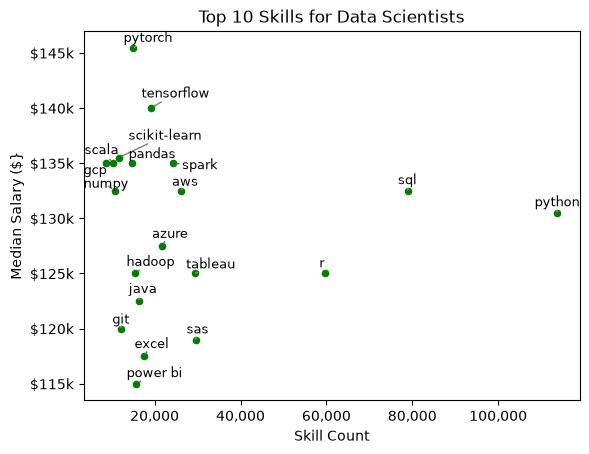

In [ ]:
from adjustText import adjust_text

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary', color='green')

texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt, fontsize=9, ha='right', va='bottom'))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='grey', lw=1))
ax = plt.gca()
ax.yaxis.set_major_formatter(lambda y, pos: f'${int(y/1000)}k')
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')
plt.title('Top 10 Skills for Data Scientists')
plt.xlabel('Skill Count')   
plt.ylabel('Median Salary ($}')



Text(0, 0.5, 'Job Counts')

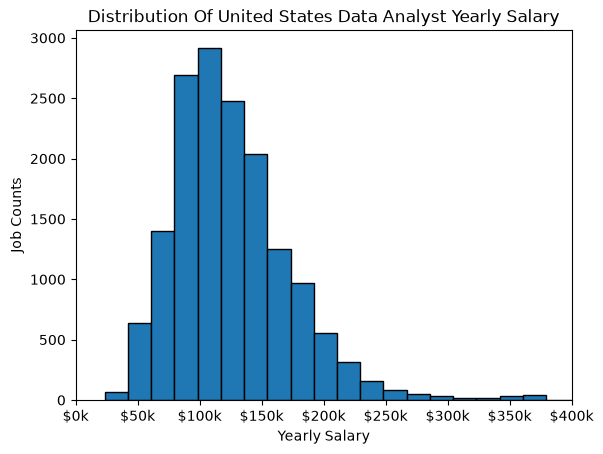

In [ ]:
from tkinter import N


df_analyst['salary_year_avg'].plot(kind='hist', bins=50, edgecolor='black')
plt.xlim(0, 400000)
ax = plt.gca()
ax.xaxis.set_major_formatter(lambda y, pos: f'${int(y/1000)}k')
plt.title('Distribution Of United States Data Analyst Yearly Salary')
plt.xlabel('Yearly Salary')
plt.ylabel('Job Counts')

In [ ]:
df_analyst=df_analyst.dropna(subset=['salary_year_avg'])
df_analyst['salary_year_avg'].sample(10)

In [ ]:
df_analyst['salary_year_avg'].sample(10)

219327     95000.0
119431     80000.0
137199    120710.0
114179    172500.0
448560    180000.0
163411    173500.0
248245    150000.0
282510    150000.0
64710      60000.0
100532    163000.0
Name: salary_year_avg, dtype: float64

<Axes: >

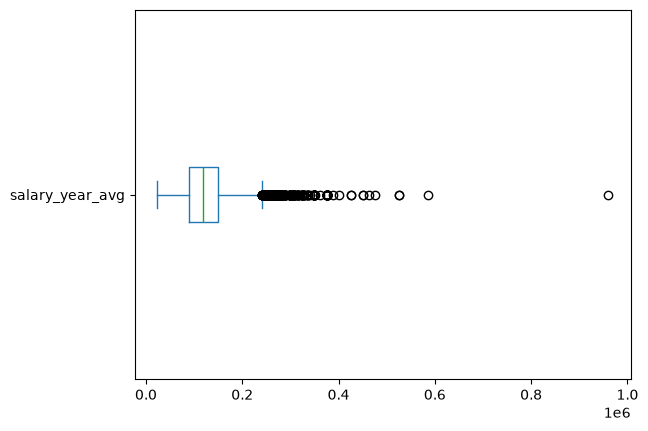

In [ ]:
df_analyst['salary_year_avg'].plot(kind= 'box', vert=False)

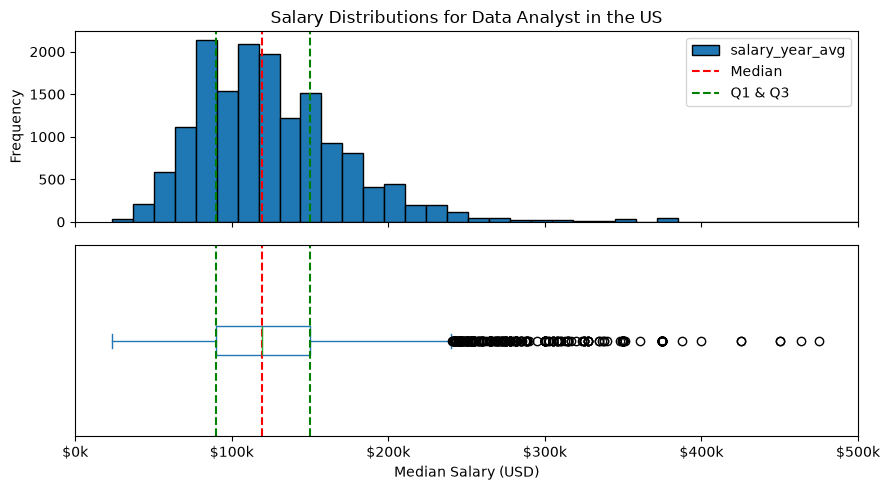

In [ ]:
fig, ax = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1, 1]}, figsize=(9, 5))

# calculate stats
median_salary = df_analyst['salary_year_avg'].median()
q1 = df_analyst['salary_year_avg'].quantile(0.25)
q3 = df_analyst['salary_year_avg'].quantile(0.75)

# top panel: histogram
df_analyst['salary_year_avg'].plot(kind='hist', bins=70, edgecolor='black', ax=ax[0])
ax[0].axvline(median_salary, color='red', linestyle='--', label='Median')
ax[0].axvline(q1, color='green', linestyle='--', label='Q1 & Q3')
ax[0].axvline(q3, color='green', linestyle='--')
ax[0].legend()
ax[0].set_title('Salary Distributions for Data Analyst in the US')
ax[0].set_ylabel('Frequency')
ax[0].set_xlabel('')

# bottom panel: boxplot
df_analyst['salary_year_avg'].plot(kind='box', vert=False, ax=ax[1])
ax[1].axvline(median_salary, color='red', linestyle='--')
ax[1].axvline(q1, color='green', linestyle='--')
ax[1].axvline(q3, color='green', linestyle='--')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_yticks([])

# shared x-axis formatting (applies to bottom panel, shared with top)
ax[1].xaxis.set_major_formatter(lambda y, pos: f'${int(y/1000)}k')
plt.xlim(0, 500000)

plt.tight_layout()
plt.show()

In [90]:

job_title = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_usa = df[(df['job_country'] == 'United States') & (df['job_title_short'].isin(job_title))].copy()
df_usa = df_usa.dropna(subset=['salary_year_avg'])

job_list = [df_usa[df_usa['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_title]

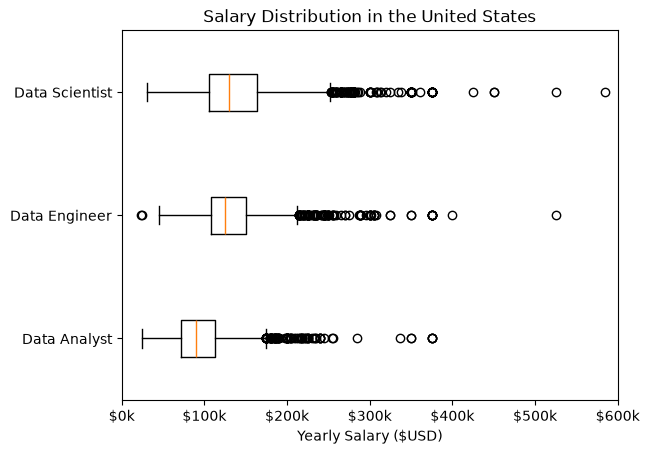

In [96]:
plt.boxplot(job_list, orientation='horizontal')
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
plt.yticks(range(1, len(job_title) + 1), job_title)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.xlim(0, 600000)
plt.show()


92        120000.0
100       228222.0
109        89000.0
116       114000.0
146       129500.0
            ...   
785563    136400.0
785624    139216.0
785641    150000.0
785648    221875.0
785692    157500.0
Name: salary_year_avg, Length: 11818, dtype: float64